![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 3. Interferometers I - MZI


Today we will work on the design and modeling of an **Mach-Zenhder Interferometer (MZI)** used in integrated photonic circuits. We will perform simulations that will allow us to understand how it operates.


## 0.1 General libraries

In [3]:
import gdsfactory as gf
import jax
import jax.example_libraries.optimizers as opt
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm

import numpy as np
import sax
from gdsfactory.generic_tech import get_generic_pdk
from scipy import constants
from scipy.constants import c
from scipy.interpolate import interp1d

import gplugins.sax as gs
from gplugins.common.config import PATH

/tmp/ipykernel_8812/3896563056.py:10: DeprecationWarning: The 'gdsfactory.generic_tech' module is deprecated and will be removed in a future version. Please update your imports to use 'gdsfactory.gpdk' instead:
  from gdsfactory.gpdk import LAYER, LAYER_STACK, get_generic_pdk
Or for submodules:
  from gdsfactory.gpdk.layer_map import LAYER
  from gdsfactory.gpdk.layer_stack import LAYER_STACK
  from gdsfactory.generic_tech import get_generic_pdk


## 1. MZI modeling
Let's compute the transfer function of a MZI

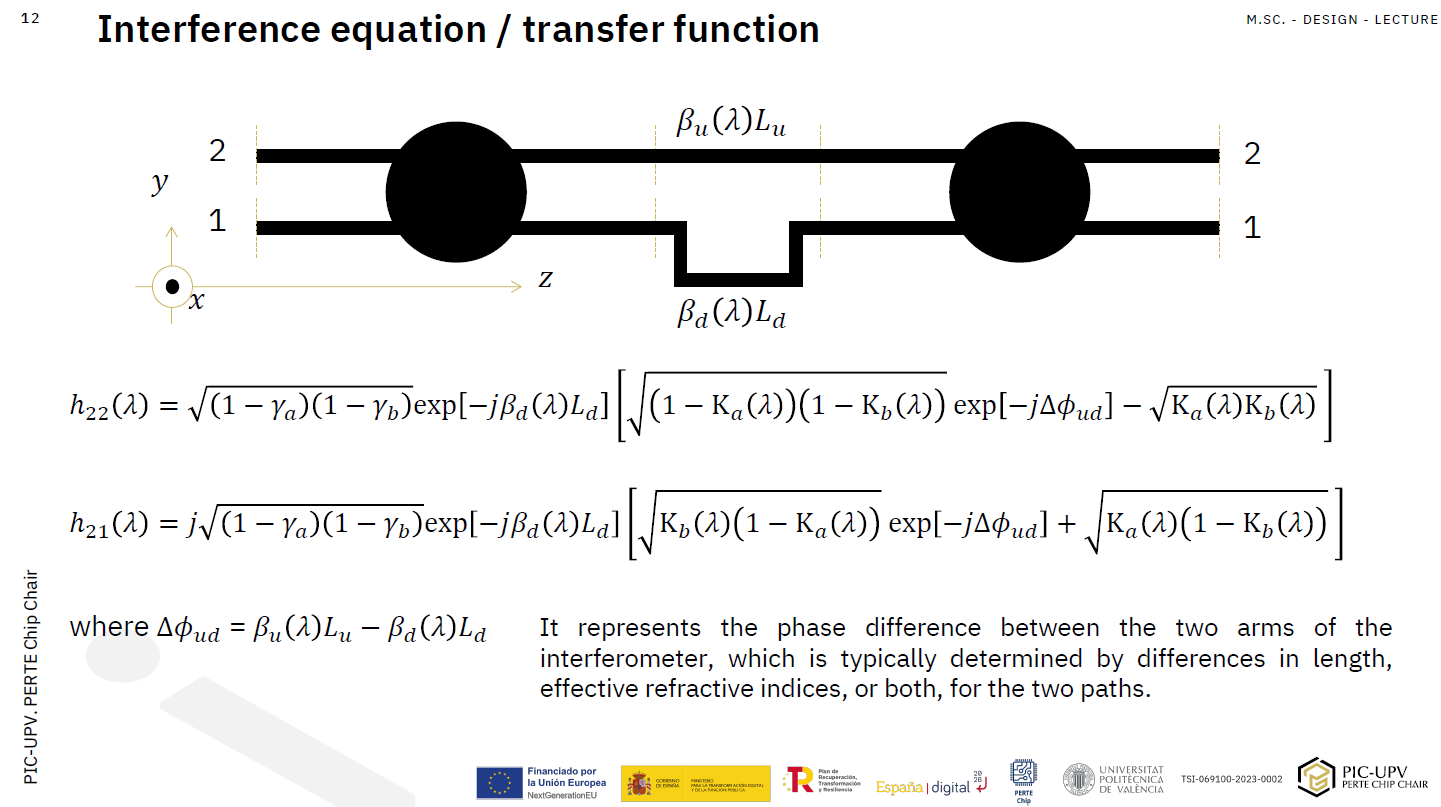

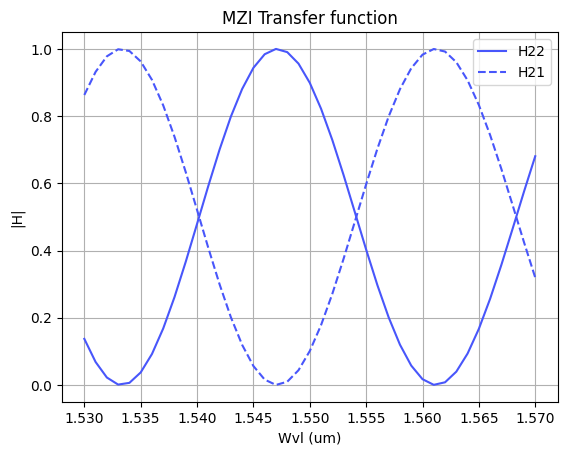

In [4]:
### Waveguides configuration ###

## Propagation parameters

## SOI cross-section ##
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0] #LA PRIMERA COL ES LA LONGITUD DE ONDA
neffu = SOI[:, 3] #balanced configuration // (neff TE mode) #UPPER ARM
neffd = SOI[:, 3] #balanced configuration // (neff TE mode) #DOWN ARM

## SiN cross-section ##
# SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
# SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')

# wvl0 = SiN_clad[:, 0]
# neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
# neffd0 = SiN_wat[:, 3] #balanced configuration // (neff TE mode)

# interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
# interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
# wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
# neffu = interp_neffu(wvl)
# neffd = interp_neffd(wvl)

# Propagation loss
alphau=0 #losless case dB/um
alphad =0 #losless case dB/um
alphau_np=(jnp.log(10.0)/10.0)*alphau #neper/um
alphad_np=(jnp.log(10.0)/10.0)*alphad #neper/um

# Path length
Lu = 25; # um LONGITUD BRAZO SUPERIOR
Ld = 5; # um LONGITUD BRAZO INFERIOR

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld

### Couplers configuration ###
# Excess loss
gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# MZI transfer function (h22 & h21)

#  h_22(wvl)
h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))

#  h_21(wvl)
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

# Plot
color = cm.rainbow(np.linspace(0, 1, 10))

plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function')
plt.legend()
plt.grid(True)

plt.show()

**Assesment 1.** Please, provide one example of each one of the configurations studied during MZI lecture:
1. Balenced configuration
2. Unbalanced configuration
  1.   Phase difference
  2.   Delay imbalance

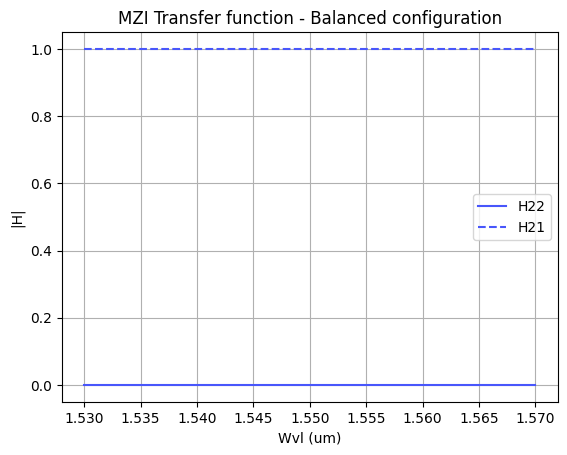

In [5]:
### BALANCED CONFIGURATION ###

SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0] 
neffu = SOI[:, 3] 
neffd = SOI[:, 3] 

Lu = 25 
Ld = 25 

alphau=0 #losless case dB/um
alphad =0 #losless case dB/um
alphau_np=(jnp.log(10.0)/10.0)*alphau #neper/um
alphad_np=(jnp.log(10.0)/10.0)*alphad #neper/um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np
Delta_phi_ud = betau*Lu - betad*Ld

gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

color = cm.rainbow(np.linspace(0, 1, 10))
plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function - Balanced configuration')
plt.legend()
plt.grid(True)
plt.show()

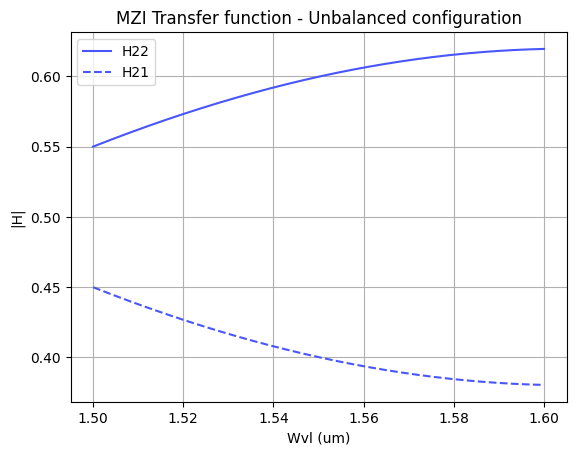

In [6]:
### UNBALANCED CONFIGURATION: DIFERENCIA DE FASE ###

## SiN cross-section ##
SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')
SiN_wat = np.loadtxt('SiN-h300nm-w1000nm-Water.txt', skiprows=1, delimiter='\t')
SiN_air = np.loadtxt('SiN-h300nm-w1000nm-Air.txt', skiprows=1, delimiter='\t')

wvl0 = SiN_clad[:, 0]
neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
neffd0 = SiN_air[:, 3] #balanced configuration // (neff TE mode)

interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
neffu = interp_neffu(wvl)
neffd = interp_neffd(wvl)

Lu = 25 
Ld = 25 

alphau=0 #losless case dB/um
alphad =0 #losless case dB/um
alphau_np=(jnp.log(10.0)/10.0)*alphau #neper/um
alphad_np=(jnp.log(10.0)/10.0)*alphad #neper/um

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np
Delta_phi_ud = betau*Lu - betad*Ld

gamma_a = 0; #null excess loss
gamma_b = 0; #null excess loss

K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

color = cm.rainbow(np.linspace(0, 1, 10))
plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function - Unbalanced configuration')
plt.legend()
plt.grid(True)
plt.show()

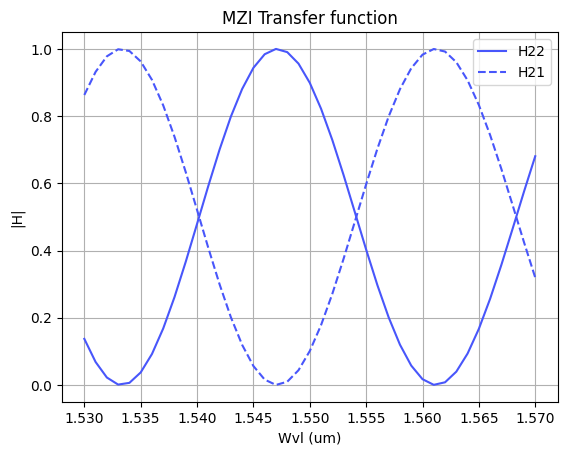

In [7]:
### UMBALANCED CONFIGURATION - DELAY IMBALANCE ###

SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0] #LA PRIMERA COL ES LA LONGITUD DE ONDA
neffu = SOI[:, 3] #balanced configuration // (neff TE mode) #UPPER ARM
neffd = SOI[:, 3] #balanced configuration // (neff TE mode) #DOWN ARM

alphau=0 #losless case dB/um
alphad =0 #losless case dB/um
alphau_np=(jnp.log(10.0)/10.0)*alphau #neper/um
alphad_np=(jnp.log(10.0)/10.0)*alphad #neper/um

Lu = 25; # um LONGITUD BRAZO SUPERIOR
Ld = 5; # um LONGITUD BRAZO INFERIOR

betau = (2*jnp.pi/wvl)*neffu-1j*alphau_np
betad = (2*jnp.pi/wvl)*neffd-1j*alphad_np

Delta_phi_ud = betau*Lu - betad*Ld

gamma_a = 0
gamma_b = 0

# Coupling constant
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)


h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*(( np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud))-(np.sqrt(K_a * K_b)))
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b)))*(np.exp(-1j * betad * Ld))*((np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud))+(np.sqrt(K_a * (1 - K_b))))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

color = cm.rainbow(np.linspace(0, 1, 10))
plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function')
plt.legend()
plt.grid(True)

plt.show()

**Assesment 2.** Taking into account the n_{eff} values for the SOI cross-section, what would be the path difference ($\Delta L$ = $L_u$ - $L_d$) needed to obtain a Free Spectral Range of 40 nm? Introduce the obtained value in the model to check the MZI response. Hint: We assume 1550 nm as the central design wavelength ($\lambda _0$=1550 nm).

Distancia necesaria de ΔL para FSR=40nm: 25.495910042151824 um


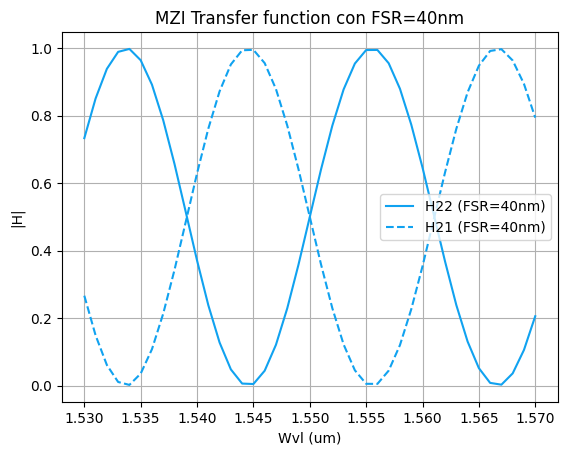

In [8]:
# Calculate path difference for FSR = 40 nm at λ0 = 1550 nm
lambda0 = 1.55  # um
FSR = 0.04      # um (40 nm)
neff_central = np.interp(lambda0, SOI[:, 0], SOI[:, 3]) 

# ΔL = λ0^2 / (n_eff * FSR)
delta_L = lambda0**2 / (neff_central * FSR)
print(f"Distancia necesaria de ΔL para FSR=40nm: {delta_L} um")

Lu = 25     
Ld = Lu - delta_L 

betau = (2 * jnp.pi / wvl)*neffu-1j*alphau_np
betad = (2 * jnp.pi / wvl)*neffd-1j*alphad_np
Delta_phi_ud = betau * Lu -betad*Ld

h_22 = (np.sqrt((1 - gamma_a) * (1 - gamma_b))) * (np.exp(-1j * betad * Ld)) * (np.sqrt((1 - K_a) * (1 - K_b)) * np.exp(-1j * Delta_phi_ud) - np.sqrt(K_a * K_b))
h_21 = (1j * np.sqrt((1 - gamma_a) * (1 - gamma_b))) * (np.exp(-1j * betad * Ld)) * (np.sqrt(K_b * (1 - K_a)) * np.exp(-1j * Delta_phi_ud) + np.sqrt(K_a * (1 - K_b)))

H21 = np.abs(h_21) ** 2
H22 = np.abs(h_22) ** 2

plt.plot(wvl, H22, linestyle='-', color=color[2], label='H22 (FSR=40nm)')
plt.plot(wvl, H21, linestyle='--', color=color[2], label='H21 (FSR=40nm)')
plt.xlabel('Wvl (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer function con FSR=40nm')
plt.legend()
plt.grid(True)
plt.show()

## 2. MZI simulation implemented with SAX
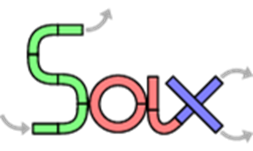

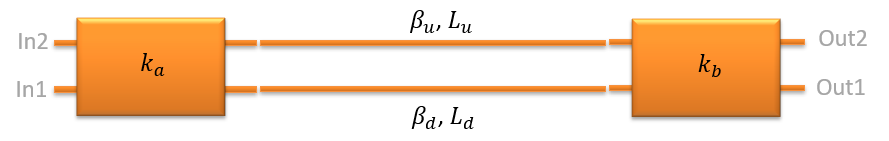


### 2.1 Components S matrix


In [9]:
# Waveguide Model
#Modelo basico de guia de onda, con parametros de perdida y fase, que se usara para construir el interferometro
def waveguide(wl=1.55, neff=1.6072, length=10.0, loss=0.0) -> sax.SDict:
    phase = 2 * jnp.pi * neff * length / wl
    transmission = 10 ** (-loss * length / 20) * jnp.exp(1j * phase) # loss(dB/um)
    wg_dict = sax.reciprocal(
        {
            ("in0", "out0"): transmission,
        }
    )
    return wg_dict


# Coupler Model
#Modelo basico de acoplador, con parametros de acoplamiento y perdida, que se usara para construir el interferometro
def coupler(coupling=0.5) -> sax.SDict:
    kappa = coupling**0.5 #acoplamiento
    tau = (1 - coupling) ** 0.5 #transmision, con la condicion de que el acoplamiento y la transmision sumen 1, es decir, que no haya perdida en el acoplador
    coupler_dict = sax.reciprocal( #acoplador reciproco, es decir, que la transferencia de in0 a out0 sea igual a la de in1 a out1, y la de in0 a out1 sea igual a la de in1 a out0
        {
            ("in0", "out0"): tau, #transmision
            ("in0", "out1"): kappa * np.exp(-1j * np.pi / 2.0), #acoplamiento con desfase de pi/2
            ("in1", "out0"): kappa * np.exp(-1j * np.pi / 2.0), #acoplamiento con desfase de pi/2
            ("in1", "out1"): tau,
        }
    )
    return coupler_dict

### 2.2 MZI SAX Circuit Model

In [10]:
# MZI

mzi, info = sax.circuit(# MZI con 2 acopladores y 2 guias de onda, con la conf. balanceada, es decir, con la misma longitud en ambos brazos, y con acoplamiento 50/50 en ambos acopladores
    netlist={# el netlist define el tipo de circuito, las instancias que lo componen, las conexiones entre ellas, y los puertos de entrada y salida del circuito
        "instances": {
            "coup_a": "coupler", #primer acoplador
            "wvg_u": "waveguide", #guia de onda del brazo superior
            "wvg_d": "waveguide",
            "coup_b": "coupler",#segundo acoplador
        },
        "connections": {
            "coup_a,out0": "wvg_d,in0", #conexion brazo inferior de la guia de onda con el primer acoplador
            "wvg_d,out0": "coup_b,in0", #conexion brazo inferior de la guia con el segundo acoplador
            "coup_a,out1": "wvg_u,in0", #conexion segundo brazo con primer acoplador
            "wvg_u,out0": "coup_b,in1", #conexion segundo brazo con segundo acoplador
        },
        "ports": {
            "in0": "coup_a,in0", #puerto entrada primer acoplador
            "in1": "coup_a,in1", #puerto entrada segundo acoplador
            "out0": "coup_b,out0", #puerto salida primer acoplador
            "out1": "coup_b,out1", #puerto salida segundo acoplador
        },
    },
    models={
        "coupler": coupler, #modelo de acoplador definido antes
        "waveguide": waveguide, #modelo guia de onda definido antes
    },
)


### 2.3. MZI Modeling
**Assesment 3**: Now, we are going to implement the design parameters in the MZI model developed in SAX and compare the response obtained with that simulated by mathematical formulation.

This will help us to identify any error in the definition of the SAX model single components.

In order to implement the SAX model, take as example the following lines:

    mzi_test = mzi(wl=wl,
                coup_a = ...
                wvg_d={"length": l_d, "neff": ...},
                wvg_u={"length": l_u, "neff": ...},
                coup_b = ... )

    H00 = mzi_test["in0", "out0"]

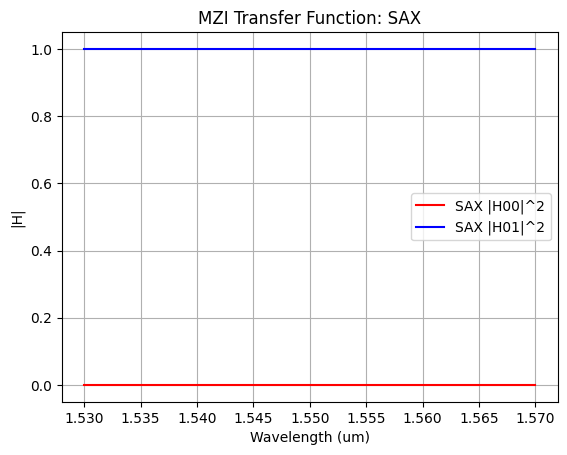

In [11]:

SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0] 
neffu = SOI[:, 3] 
neffd = SOI[:, 3] 
Lu = 25 
Ld = 25 
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

mzi_test = mzi(
    wl=wvl,
    coup_a={"coupling": K_a},
    wvg_d={"neff": neffd, "length": Ld},
    wvg_u={"neff": neffu, "length": Lu},
    coup_b={"coupling": K_b},
)

H00 = mzi_test["in0", "out0"]
H01 = mzi_test["in0", "out1"]


# Plot comparison
plt.figure()
plt.plot(wvl, np.abs(H00)**2, color='red', label="SAX |H00|^2")
plt.plot(wvl, np.abs(H01)**2, color='blue', label="SAX |H01|^2")
#plt.plot(wvl, H22, linestyle='-', color='red', label='Math |H22|')
#plt.plot(wvl, H21, linestyle='--', color='red', label='Math |H21|')
plt.xlabel('Wavelength (um)')
plt.ylabel('|H|')
plt.title('MZI Transfer Function: SAX')
plt.legend()
plt.grid(True)
plt.show()


**Assessment 4.** Designing an MZI for filtering at a specific wavelength. Calculate and adjust the arm lengths to configure the MZI to have a maximum transmission at 1550 nm.

**Assessment 5.** Let's see how the response of the MZI variates with the effective index. Vary the effective index of one of the arms and analyze how the spectrum shifts. To do this, you can use the data provided in the .txt files entitled ‘SiN’.
Can you give an example of an application where this configuration is used?

**Assessment 6.** Explore how cascading two MZIs affects the transmission spectrum. To do so, design a system in which two MZIs are cascaded. Simulate and observe the spectrum, explaining how the transmission peaks behave.

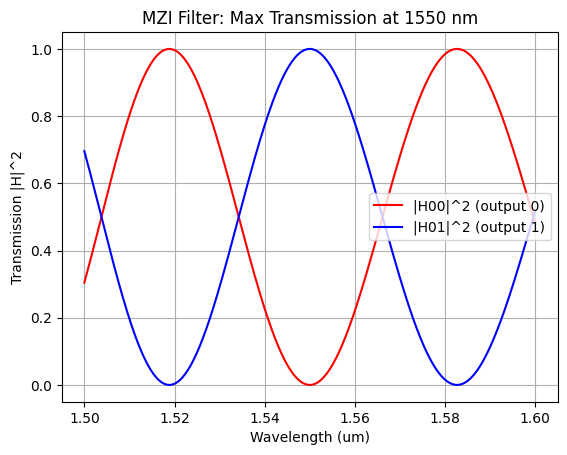

In [14]:
# ASSESSMENT 4#

SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')

wvl0 = SiN_clad[:, 0]
neffu0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)
neffd0 = SiN_clad[:, 3] #balanced configuration // (neff TE mode)

interp_neffu = interp1d(wvl0, neffu0, kind='cubic')  # Cubic interpolation for smoothness
interp_neffd = interp1d(wvl0, neffd0, kind='cubic')
wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
neffu = interp_neffu(wvl)
neffd = interp_neffd(wvl)

lambda0 = 1.55  # um (target wavelength)
neff_central_u = np.interp(lambda0, wvl, neffu)
neff_central_d = np.interp(lambda0, wvl, neffd)

# For constructive interference at output (max transmission at lambda0):
# The phase difference Δφ = 2π * (neff_u * Lu - neff_d * Ld) / lambda0 = 0 mod 2π


# Para interferencia constructiva en H00 (Bar port): Delta_phi = m * 2*pi
# Delta_L = m * lambda0 / neff_central
m = 20 
delta_L = m * lambda0 / neff_central_u

# Asignamos las longitudes
Ld = 50.0
Lu = Ld + delta_L  # El brazo superior es más largo


K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

# SAX simulation
mzi_filter = mzi(
    wl=wvl,
    coup_a={"coupling": K_a},
    wvg_d={"neff": neffd, "length": Ld},
    wvg_u={"neff": neffu, "length": Lu},
    coup_b={"coupling": K_b},
)

H00 = mzi_filter["in0", "out0"]
H01 = mzi_filter["in0", "out1"]

plt.figure()
plt.plot(wvl, np.abs(H00)**2, color='red', label="|H00|^2 (output 0)")
plt.plot(wvl, np.abs(H01)**2, color='blue', label="|H01|^2 (output 1)")
plt.xlabel('Wavelength (um)')
plt.ylabel('Transmission |H|^2')
plt.title('MZI Filter: Max Transmission at 1550 nm')
plt.legend()
plt.grid(True)
plt.show()

<>:55: SyntaxWarning: invalid escape sequence '\l'
<>:55: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_8812/2395209008.py:55: SyntaxWarning: invalid escape sequence '\l'
  plt.axvline(lambda0, color='black', linestyle=':', linewidth=2, label='Target $\lambda_0 = 1.55 \mu m$')


Para m=20, el Delta L necesario es: 19.6934 um


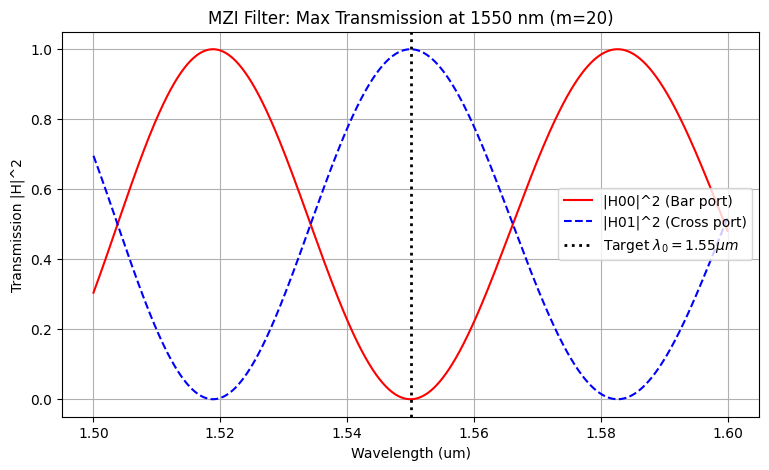

In [13]:
# ASSESSMENT 4 - CORRECTED

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# 1. Usamos SiN_clad para AMBOS brazos (filtro estándar por retardo)
SiN_clad = np.loadtxt('SiN-h300nm-w1000nm-Cladding.txt', skiprows=1, delimiter='\t')

wvl0 = SiN_clad[:, 0]
neff_clad = SiN_clad[:, 3] 

# Interpolamos para tener una curva suave
interp_neff = interp1d(wvl0, neff_clad, kind='cubic')
wvl = np.linspace(wvl0.min(), wvl0.max(), 1000)
neff_array = interp_neff(wvl)

# 2. Definimos el objetivo
lambda0 = 1.55  # um (target wavelength)
neff_central = np.interp(lambda0, wvl, neff_array)

# 3. Diseño del filtro: Calculamos Delta L
# Para interferencia constructiva en H00 (Bar port): Delta_phi = m * 2*pi
# Delta_L = m * lambda0 / neff_central
m = 20  # Elegimos un orden de interferencia m > 0 para que haya picos y valles
delta_L = m * lambda0 / neff_central

print(f"Para m={m}, el Delta L necesario es: {delta_L:.4f} um")

# Asignamos las longitudes
Ld = 50.0
Lu = Ld + delta_L  # El brazo superior es más largo

# 4. Simulación SAX
K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.5)

mzi_filter = mzi(
    wl=wvl,
    coup_a={"coupling": K_a},
    wvg_d={"neff": neff_array, "length": Ld}, # Usamos el mismo neff_array
    wvg_u={"neff": neff_array, "length": Lu}, # Usamos el mismo neff_array
    coup_b={"coupling": K_b},
)

H00 = mzi_filter["in0", "out0"]
H01 = mzi_filter["in0", "out1"]

# 5. Visualización
plt.figure(figsize=(9, 5))
plt.plot(wvl, np.abs(H00)**2, color='red', label="|H00|^2 (Bar port)")
plt.plot(wvl, np.abs(H01)**2, color='blue', linestyle='--', label="|H01|^2 (Cross port)")

# Línea vertical para comprobar que el pico cae exactamente en 1550 nm
plt.axvline(lambda0, color='black', linestyle=':', linewidth=2, label='Target $\lambda_0 = 1.55 \mu m$')

plt.xlabel('Wavelength (um)')
plt.ylabel('Transmission |H|^2')
plt.title(f'MZI Filter: Max Transmission at {lambda0*1000:.0f} nm (m={m})')
plt.legend()
plt.grid(True)
plt.show()